# Learner Trajectory Analysis

This notebook is the **external testing tool** for the Moodle trajectory extraction plugin.

It calls the plugin's REST API to fetch raw learner navigation data and performs basic
Educational Data Mining (EDM) analysis:

1. Fetch trajectory events from Moodle via the web service API
2. Analyse **time spent** per activity
3. Discover the most common **navigation sequences** (learner paths)
4. Produce a **per-user summary**
5. Compare **quiz outcomes** with time spent on related file resources
6. Analyse **H5P xAPI statements** (verb distribution, completion rates, scores)

In [146]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv('/Users/ece/Desktop/moodle/testing/.env', override=True)

MOODLE_URL = os.getenv("MOODLE_URL", "http://localhost:8081")
TOKEN      = os.getenv("MOODLE_TOKEN")

if not TOKEN:
    raise ValueError("MOODLE_TOKEN not set. Add it to the .env file in the project root.")

## 1. Fetch Trajectory Data from Moodle

The plugin exposes a REST endpoint. We authenticate with the token and optionally
filter by `courseid`, `userid`, or `since` (Unix timestamp).

Use the course dropdown below to focus all analysis on a single course.

In [147]:
def get_trajectories(courseid=0, userid=0, since=0):
    """Call the Moodle web service and return trajectory events as a list of dicts."""
    params = {
        "wstoken":            TOKEN,
        "wsfunction":         "local_nextclicks_get_trajectories",
        "moodlewsrestformat": "json",
        "courseid":           courseid,
        "userid":             userid,
        "since":              since,
    }
    resp = requests.get(f"{MOODLE_URL}/webservice/rest/server.php", params=params)
    resp.raise_for_status()
    data = resp.json()
    if isinstance(data, dict) and "exception" in data:
        raise Exception(f"Moodle API error: {data.get('message', data)}")
    return data

# Fetch all once to build available course options.
all_raw = get_trajectories()
course_ids = sorted({int(r["courseid"]) for r in all_raw})
selected_courseid = int(globals().get("SELECTED_COURSEID", 0))

try:
    import ipywidgets as widgets
    from IPython.display import display

    previous_courseid = int(course_dropdown.value) if "course_dropdown" in globals() else 0
    default_courseid = previous_courseid if previous_courseid in ([0] + course_ids) else 0
    course_dropdown = widgets.Dropdown(
        options=[("All courses", 0)] + [(f"Course {cid}", cid) for cid in course_ids],
        value=default_courseid,
        description="Course:",
        layout=widgets.Layout(width="320px"),
    )
    display(course_dropdown)
    selected_courseid = int(globals().get("SELECTED_COURSEID", course_dropdown.value))
    print("Dropdown should appear directly below this cell output.")
    print("If it does not render in your UI, set SELECTED_COURSEID=<id> in a new cell and re-run this cell.")
except ImportError:
    print("ipywidgets is not installed. Using manual fallback.")
    print("Set SELECTED_COURSEID=<id> in a new cell, or install ipywidgets with: pip install ipywidgets")

raw = get_trajectories(courseid=selected_courseid)
print(f"Fetched {len(raw)} trajectory events for courseid={selected_courseid or 'ALL'}")
raw[:3]

ipywidgets is not installed. Using manual fallback.
Set SELECTED_COURSEID=<id> in a new cell, or install ipywidgets with: pip install ipywidgets
Fetched 273 trajectory events for courseid=ALL


[{'id': 1,
  'userid': 2,
  'courseid': 2,
  'itemtype': 'course',
  'itemid': 2,
  'timecreated': 1772574007,
  'timespent': 384},
 {'id': 2,
  'userid': 2,
  'courseid': 2,
  'itemtype': 'course',
  'itemid': 2,
  'timecreated': 1772574391,
  'timespent': 12},
 {'id': 3,
  'userid': 2,
  'courseid': 2,
  'itemtype': 'cm',
  'itemid': 1,
  'timecreated': 1772574403,
  'timespent': 2}]

In [ ]:
df = pd.DataFrame(raw)

if df.empty:
    print("No trajectory data yet. Log into Moodle, browse some courses, then re-run this cell.")
    df = pd.DataFrame(columns=["id","userid","courseid","itemtype","itemid","timecreated","timespent","datetime","label"])
else:
    df["datetime"] = pd.to_datetime(df["timecreated"], unit="s")
    df["label"] = df["itemtype"] + ":" + df["itemid"].astype(str)
    df = df.sort_values(["userid", "timecreated"]).reset_index(drop=True)

df.tail(10)


## 2. Time Spent per Activity

`timespent` (seconds) is calculated server-side by the plugin: it is the gap between
this event and the next event for the same user in the same course.
A value of `0` means the event was the last one in the session (unknown duration).

In [149]:
# Only include events where we know the time spent
timed = df[df["timespent"] > 0].copy()

avg_time = (
    timed.groupby("label")["timespent"]
    .agg(visits="count", avg_seconds="mean", total_seconds="sum")
    .sort_values("avg_seconds", ascending=False)
    .reset_index()
)
avg_time["avg_minutes"] = (avg_time["avg_seconds"] / 60).round(2)
avg_time

,label,visits,avg_seconds,total_seconds,avg_minutes
0,cm:1,3,548.666667,1646,9.14
1,course:2,83,118.746988,9856,1.98
2,course:3,42,111.023810,4663,1.85
3,cm:2,28,77.285714,2164,1.29
4,cm:4,53,61.207547,3244,1.02
5,cm:10,20,43.100000,862,0.72
6,cm:6,1,16.000000,16,0.27
7,cm:9,11,11.636364,128,0.19
8,cm:5,1,6.000000,6,0.10
9,cm:3,1,5.000000,5,0.08


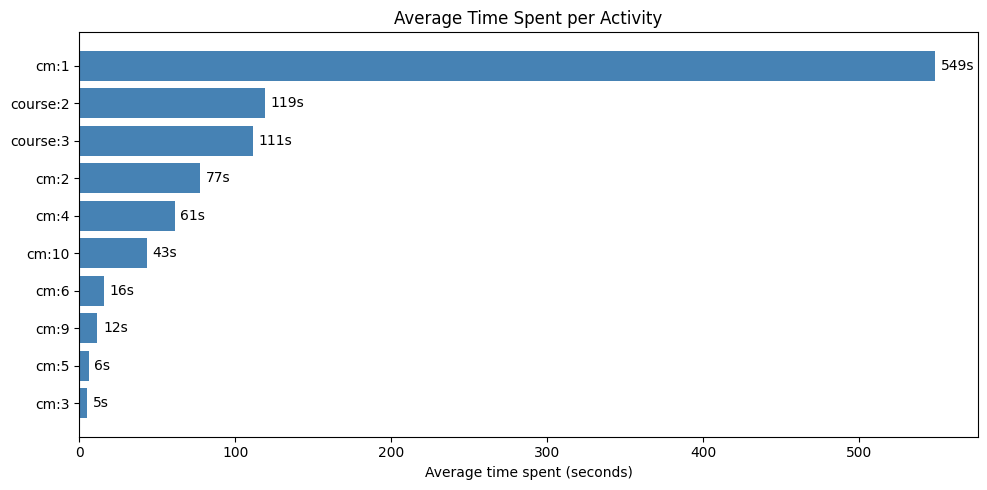

In [150]:
fig, ax = plt.subplots(figsize=(10, max(4, len(avg_time) * 0.5)))
bars = ax.barh(avg_time["label"], avg_time["avg_seconds"], color="steelblue")
ax.bar_label(bars, labels=[f"{v:.0f}s" for v in avg_time["avg_seconds"]], padding=4)
ax.set_xlabel("Average time spent (seconds)")
ax.set_title("Average Time Spent per Activity")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Navigation Sequences (Learner Paths)

We reconstruct each learner's full navigation path and find the most common
two-step transitions.

In [151]:
# Build the ordered sequence of pages visited per user
sequences = (
    df.sort_values(["userid", "timecreated"])
    .groupby("userid")["label"]
    .apply(list)
    .reset_index()
)
sequences.columns = ["userid", "path"]
sequences["path_str"] = sequences["path"].apply(lambda p: " → ".join(p))
sequences[["userid", "path_str"]]

,userid,path_str
0,2,course:2 → course:2 → cm:1 → course:2 → cm:1 →...
1,3,course:2 → cm:4 → course:2 → course:2 → cm:4 →...


In [152]:
# Extract all two-step transitions across all users
def bigrams(seq):
    return [(seq[i], seq[i + 1]) for i in range(len(seq) - 1)]

all_transitions = []
for path in sequences["path"]:
    all_transitions.extend(bigrams(path))

top_transitions = pd.DataFrame(
    Counter(all_transitions).most_common(10),
    columns=["transition", "count"]
)
top_transitions["transition"] = top_transitions["transition"].apply(
    lambda t: f"{t[0]}  →  {t[1]}"
)
top_transitions

,transition,count
0,course:2 → course:2,40
1,cm:4 → cm:4,33
2,course:3 → course:3,20
3,course:2 → cm:4,18
4,cm:4 → course:2,17
5,course:2 → cm:2,16
6,cm:10 → cm:10,12
7,cm:2 → course:2,12
8,course:3 → cm:10,10
9,cm:2 → cm:2,10


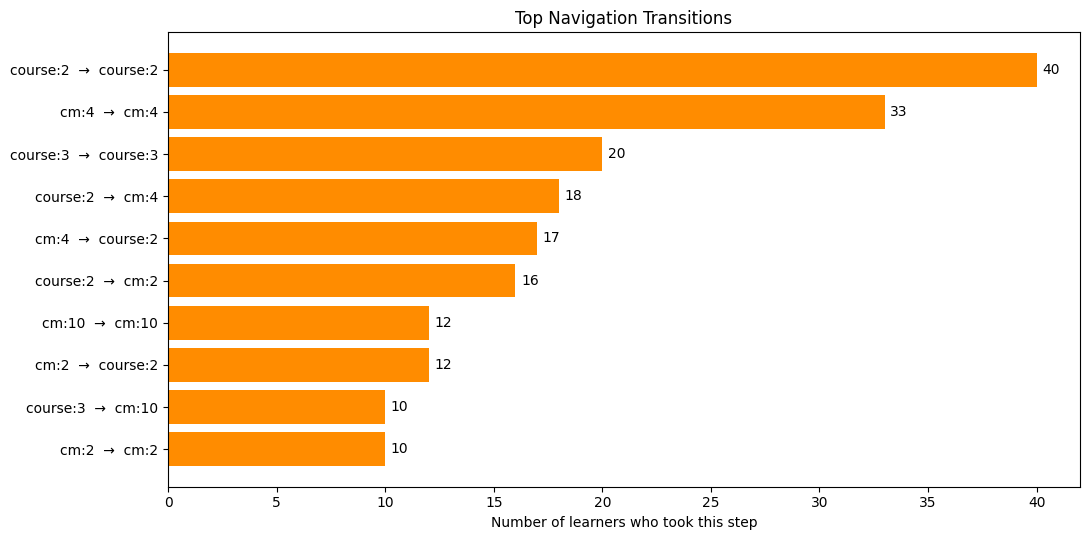

In [153]:
fig, ax = plt.subplots(figsize=(11, max(4, len(top_transitions) * 0.55)))
bars = ax.barh(top_transitions["transition"], top_transitions["count"], color="darkorange")
ax.bar_label(bars, padding=4)
ax.set_xlabel("Number of learners who took this step")
ax.set_title("Top Navigation Transitions")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Per-User Summary

A high-level view of each learner's engagement: how many pages they visited,
how long they spent in total, and how many unique activities they explored.

In [154]:
summary = (
    df.groupby("userid")
    .agg(
        total_events       = ("id",          "count"),
        unique_activities  = ("label",        "nunique"),
        total_time_seconds = ("timespent",    "sum"),
        first_seen         = ("datetime",     "min"),
        last_seen          = ("datetime",     "max"),
    )
    .reset_index()
)
summary["total_time_minutes"]    = (summary["total_time_seconds"] / 60).round(2)
summary["session_span_minutes"]  = (
    (summary["last_seen"] - summary["first_seen"]).dt.total_seconds() / 60
).round(2)
summary

,userid,total_events,unique_activities,total_time_seconds,first_seen,last_seen,total_time_minutes,session_span_minutes
0,2,255,10,21796,2026-03-03 21:40:07,2026-06-05 16:43:43,363.27,135063.60
1,3,18,4,794,2026-06-05 16:26:04,2026-06-05 16:39:18,13.23,13.23


## 5. Quiz Pass vs File Time (Same Section)

This section lets you select `courseid` and `sectionid` first.
Then it finds file and quiz activities in that section, detects students who passed the selected quiz,
and plots time spent by those passers on section file/quiz activities.

In [155]:
class _CellStop(Exception): pass
try:
    import os
    import json
    import requests
    import pandas as pd
    
    try:
        from dotenv import load_dotenv, find_dotenv
        load_dotenv('/Users/ece/Desktop/moodle/testing/.env', override=True)
    except ImportError:
        pass
    
    MOODLE_URL = os.getenv("MOODLE_URL") or globals().get("MOODLE_URL") or "http://localhost:8081"
    TOKEN = os.getenv("MOODLE_TOKEN") or globals().get("TOKEN")
    if not TOKEN:
        raise ValueError("MOODLE_TOKEN not set. Run the config cell first or add MOODLE_TOKEN to the .env file in the project root.")
    
    # Type the IDs you want here, then run this cell and the chart cell below.
    # Use the table printed by this cell to choose quiz/file cmid values.
    ANALYSIS_COURSEID = 3
    ANALYSIS_SECTIONID = 1
    ANALYSIS_QUIZ_ITEMID = 10
    ANALYSIS_FILE_ITEMID = 9
    
    
    def ws_call_controls(wsfunction, **kwargs):
        params = {
            "wstoken": TOKEN,
            "wsfunction": wsfunction,
            "moodlewsrestformat": "json",
        }
        params.update(kwargs)
        resp = requests.get(f"{MOODLE_URL}/webservice/rest/server.php", params=params)
        resp.raise_for_status()
        data = resp.json()
        if isinstance(data, dict) and "exception" in data:
            raise RuntimeError(f"{wsfunction} failed: {data.get('message', data)}")
        return data
    
    
    def module_quiz_close_time(module):
        for date in module.get("dates", []) or []:
            if date.get("dataid") == "timeclose" and int(date.get("timestamp", 0)) > 0:
                return int(date["timestamp"])
        customdata = module.get("customdata")
        if customdata:
            try:
                parsed = json.loads(customdata)
                if isinstance(parsed, str):
                    parsed = json.loads(parsed)
                if isinstance(parsed, dict):
                    return int(parsed.get("timeclose") or 0)
            except (TypeError, ValueError, json.JSONDecodeError):
                return 0
        return 0
    
    
    def get_trajectories(courseid=0, userid=0, since=0):
        return ws_call_controls(
            "local_nextclicks_get_trajectories",
            courseid=courseid,
            userid=userid,
            since=since,
        )
    
    print("Fetching trajectory data...")
    raw = get_trajectories()
    df = pd.DataFrame(raw)
    if df.empty:
        print("No trajectory data yet. Browse Moodle first, then re-run.")
        raise _CellStop()
    df["datetime"] = pd.to_datetime(df["timecreated"], unit="s")
    df["label"] = df["itemtype"].astype(str) + ":" + df["itemid"].astype(str)
    
    course_options = sorted(df["courseid"].astype(int).unique().tolist())
    print("Available courses with trajectory data:")
    for courseid in course_options:
        print(f"  courseid={courseid}")
    
    if ANALYSIS_COURSEID not in course_options:
        print(f"No data for course {ANALYSIS_COURSEID} yet. Available: {course_options}")
        raise _CellStop()
    
    contents = ws_call_controls("core_course_get_contents", courseid=ANALYSIS_COURSEID)
    rows = []
    for section in contents:
        section_number = int(section.get("section", 0))
        section_id = int(section.get("id", 0))
        section_name = section.get("name") or f"Section {section_number}"
        for module in section.get("modules", []):
            if module.get("modname") in {"quiz", "resource", "file"}:
                rows.append({
                    "section": section_number,
                    "section_record_id": section_id,
                    "section_name": section_name,
                    "modtype": module.get("modname"),
                    "cmid": int(module.get("id", 0)),
                    "name": module.get("name"),
                    "quiz_timeclose": module_quiz_close_time(module) if module.get("modname") == "quiz" else 0,
                })
    
    if not rows:
        print(f"Course {ANALYSIS_COURSEID} has no quiz or file/resource modules yet.")
        raise _CellStop()
    
    available_df = pd.DataFrame(rows)
    display(available_df)
    
    section_numbers = set(available_df["section"].astype(int))
    section_record_ids = set(available_df["section_record_id"].astype(int))
    if ANALYSIS_SECTIONID in section_record_ids and ANALYSIS_SECTIONID not in section_numbers:
        selected_sectionnum = int(available_df.loc[available_df["section_record_id"] == ANALYSIS_SECTIONID, "section"].iloc[0])
    else:
        selected_sectionnum = ANALYSIS_SECTIONID
    
    section_df = available_df[available_df["section"].astype(int) == int(selected_sectionnum)]
    quiz_options = sorted(section_df.loc[section_df["modtype"] == "quiz", "cmid"].astype(int).tolist())
    file_options = sorted(section_df.loc[section_df["modtype"].isin(["resource", "file"]), "cmid"].astype(int).tolist())
    
    if not quiz_options:
        print(f"No quiz found in section {selected_sectionnum}. Add a quiz to this section first.")
        raise _CellStop()
    if not file_options:
        print(f"No file/resource found in section {selected_sectionnum}. Add a file resource first.")
        raise _CellStop()
    if ANALYSIS_QUIZ_ITEMID not in quiz_options:
        print(f"ANALYSIS_QUIZ_ITEMID {ANALYSIS_QUIZ_ITEMID} not found. Available quizzes: {quiz_options}")
        raise _CellStop()
    if ANALYSIS_FILE_ITEMID not in file_options:
        print(f"ANALYSIS_FILE_ITEMID {ANALYSIS_FILE_ITEMID} not found. Available files: {file_options}")
        raise _CellStop()
    
    print(
        f"Active selection -> courseid={ANALYSIS_COURSEID}, "
        f"sectionid={ANALYSIS_SECTIONID}, "
        f"quiz_itemid={ANALYSIS_QUIZ_ITEMID}, "
        f"file_itemid={ANALYSIS_FILE_ITEMID}"
    )
    print("Now run the chart cell directly below this one.")

except _CellStop:
    pass


Fetching trajectory data...
Available courses with trajectory data:
  courseid=2
  courseid=3


,section,section_record_id,section_name,modtype,cmid,name,quiz_timeclose
0,1,8,1,resource,9,1.1,0
1,1,8,1,quiz,10,1.2,0


Active selection -> courseid=3, sectionid=1, quiz_itemid=10, file_itemid=9
Now run the chart cell directly below this one.


In [156]:
# Compatibility helper for older chart cells.
# Run this before the Analysis 5 bar chart cell if it says get_trajectories is not defined.
def get_trajectories(courseid=0, userid=0, since=0):
    return ws_call_controls(
        "local_nextclicks_get_trajectories",
        courseid=courseid,
        userid=userid,
        since=since,
    )

print("get_trajectories helper is ready.")


get_trajectories helper is ready.


Fetching fresh course trajectory data...


,group,students,avg_file_time_seconds
0,Passed,0,0.0
1,Failed,1,117.0



Data source summary:
  Dwell pings (accurate):              0 user(s) []
  Trajectory fallback (overestimate):  1 user(s) [2]
  ⚠ Trajectory fallback was used. The file resource likely opens in a new tab.
    File times for these users include idle time after closing the file.
    Consider setting the file display mode to 'Embed' for accurate dwell tracking.

Note: gradepass not returned by API for at least one user; fallback rule used (grade > 0 => Passed).

Selected file: cm:9 (1.1)
Selected quiz: cm:10 (1.2)
Quiz has no close deadline; counting file time until each student's final allowed attempt. Limit: 1
Student cutoffs: {2: 1779577846}


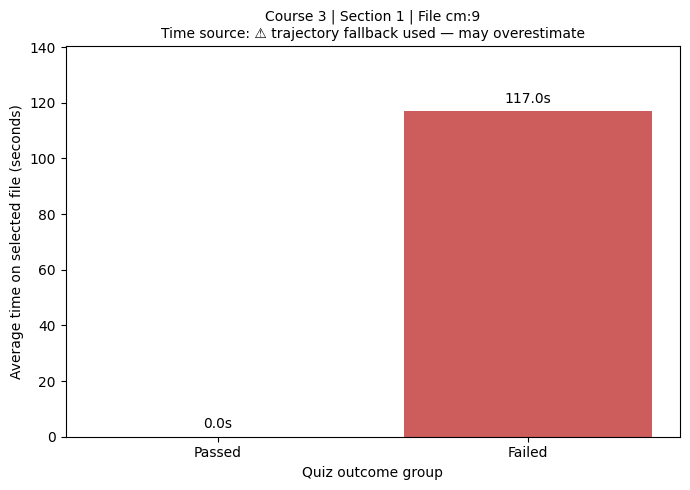

In [157]:
class _CellStop(Exception): pass
try:
    import os
    import json
    import requests
    import pandas as pd
    import matplotlib.pyplot as plt

    try:
        from dotenv import load_dotenv, find_dotenv
        load_dotenv('/Users/ece/Desktop/moodle/testing/.env', override=True)
    except ImportError:
        pass

    MOODLE_URL = os.getenv("MOODLE_URL") or globals().get("MOODLE_URL") or "http://localhost:8081"
    TOKEN = os.getenv("MOODLE_TOKEN") or globals().get("TOKEN")
    if not TOKEN:
        print("Section 5: MOODLE_TOKEN not set. Run the config cell first or add MOODLE_TOKEN to .env.")
        raise _CellStop()

    required = ["ANALYSIS_COURSEID", "ANALYSIS_SECTIONID", "ANALYSIS_QUIZ_ITEMID", "ANALYSIS_FILE_ITEMID"]
    missing = [name for name in required if name not in globals()]
    if missing:
        print(f"Section 5: Run the Analysis 5 selection cell first. Missing: {missing}")
        raise _CellStop()


    def flatten_params(params):
        flat = {}
        for key, value in params.items():
            if isinstance(value, (list, tuple)):
                for index, item in enumerate(value):
                    flat[f"{key}[{index}]"] = item
            else:
                flat[key] = value
        return flat


    def ws_call(wsfunction, **kwargs):
        params = {
            "wstoken": TOKEN,
            "wsfunction": wsfunction,
            "moodlewsrestformat": "json",
        }
        params.update(flatten_params(kwargs))
        resp = requests.get(f"{MOODLE_URL}/webservice/rest/server.php", params=params)
        resp.raise_for_status()
        data = resp.json()
        if isinstance(data, dict) and "exception" in data:
            raise RuntimeError(f"{wsfunction} failed: {data.get('message', data)}")
        return data


    def get_trajectories(courseid=0, userid=0, since=0):
        return ws_call("local_nextclicks_get_trajectories", courseid=courseid, userid=userid, since=since)


    def to_float(value):
        try:
            return float(value)
        except (TypeError, ValueError):
            return None


    def get_quiz_close_time(quiz_module):
        for date in quiz_module.get("dates", []) or []:
            if date.get("dataid") == "timeclose" and int(date.get("timestamp", 0)) > 0:
                return int(date["timestamp"])
        customdata = quiz_module.get("customdata")
        if customdata:
            try:
                parsed = json.loads(customdata)
                if isinstance(parsed, str):
                    parsed = json.loads(parsed)
                if isinstance(parsed, dict):
                    return int(parsed.get("timeclose") or 0)
            except (TypeError, ValueError, json.JSONDecodeError):
                return 0
        return 0


    def get_selected_quiz_attempt_limit(courseid, quiz_instance):
        response = ws_call("mod_quiz_get_quizzes_by_courses", courseids=[courseid])
        for quiz in response.get("quizzes", []):
            if int(quiz.get("id", 0)) == int(quiz_instance):
                return int(quiz.get("attempts") or 0)
        return 0


    def get_user_attempt_cutoff(quiz_instance, userid, attempt_limit):
        if attempt_limit <= 0:
            return 0
        response = ws_call(
            "mod_quiz_get_user_attempts", quizid=quiz_instance,
            userid=userid, status="all", includepreviews=0,
        )
        attempts = [a for a in response.get("attempts", []) if int(a.get("preview", 0)) == 0]
        finished = [a for a in attempts if a.get("state") == "finished" and int(a.get("timefinish") or 0) > 0]
        if len(finished) < attempt_limit:
            return 0
        return max(int(a.get("timefinish") or 0) for a in finished)


    print("Fetching fresh course trajectory data...")
    course_df = pd.DataFrame(get_trajectories(courseid=ANALYSIS_COURSEID))
    if course_df.empty:
        print("No trajectory events for this course yet. Browse Moodle first.")
        raise _CellStop()
    course_df["datetime"] = pd.to_datetime(course_df["timecreated"], unit="s")

    contents = ws_call("core_course_get_contents", courseid=ANALYSIS_COURSEID)
    module_by_cmid = {}
    for section in contents:
        secnum = int(section.get("section", 0))
        secid = int(section.get("id", 0))
        for mod in section.get("modules", []):
            cmid = int(mod.get("id", 0))
            module_by_cmid[cmid] = {
                "cmid": cmid, "name": mod.get("name", f"cm:{cmid}"),
                "modname": mod.get("modname", ""), "instance": int(mod.get("instance", 0)),
                "section": secnum, "sectionid": secid,
                "customdata": mod.get("customdata"), "dates": mod.get("dates", []),
            }

    section_numbers = {m["section"] for m in module_by_cmid.values()}
    section_ids     = {m["sectionid"] for m in module_by_cmid.values()}
    if ANALYSIS_SECTIONID in section_numbers:
        selected_sectionnum = ANALYSIS_SECTIONID
    elif ANALYSIS_SECTIONID in section_ids:
        selected_sectionnum = next(m["section"] for m in module_by_cmid.values() if m["sectionid"] == ANALYSIS_SECTIONID)
    else:
        selected_sectionnum = ANALYSIS_SECTIONID

    selected_quiz = module_by_cmid.get(int(ANALYSIS_QUIZ_ITEMID))
    selected_file = module_by_cmid.get(int(ANALYSIS_FILE_ITEMID))
    if selected_quiz is None or selected_quiz.get("modname") != "quiz" or selected_quiz.get("section") != selected_sectionnum:
        print("Section 5: Selected quiz item is not a quiz in the selected section. Re-run the selection cell and check the table.")
        raise _CellStop()
    if selected_file is None or selected_file.get("modname") not in {"resource", "file"} or selected_file.get("section") != selected_sectionnum:
        print("Section 5: Selected file item is not a file/resource in the selected section. Re-run the selection cell and check the table.")
        raise _CellStop()

    quiz_instance      = int(selected_quiz["instance"])
    quiz_close_time    = get_quiz_close_time(selected_quiz)
    quiz_attempt_limit = get_selected_quiz_attempt_limit(ANALYSIS_COURSEID, quiz_instance)

    candidate_users = sorted(course_df["userid"].astype(int).unique().tolist())
    user_cutoffs = {}
    for uid in candidate_users:
        if quiz_close_time > 0:
            user_cutoffs[uid] = quiz_close_time
        elif quiz_attempt_limit > 0:
            cutoff = get_user_attempt_cutoff(quiz_instance, uid, quiz_attempt_limit)
            if cutoff > 0:
                user_cutoffs[uid] = cutoff

    passers, failers, skipped_without_grade = [], [], []
    used_gradepass_fallback = False

    for uid in candidate_users:
        grades = ws_call("gradereport_user_get_grade_items", courseid=ANALYSIS_COURSEID, userid=uid)
        usergrades = grades.get("usergrades", []) if isinstance(grades, dict) else []
        quiz_grade_item = None
        for ug in usergrades:
            for gi in ug.get("gradeitems", []):
                if gi.get("itemmodule") == "quiz" and int(gi.get("iteminstance", 0)) == quiz_instance:
                    quiz_grade_item = gi
                    break
            if quiz_grade_item is not None:
                break
        if quiz_grade_item is None:
            skipped_without_grade.append(uid)
            continue
        grade_raw  = to_float(quiz_grade_item.get("graderaw"))
        grade_pass = to_float(quiz_grade_item.get("gradepass"))
        if grade_raw is None:
            skipped_without_grade.append(uid)
            continue
        if grade_pass is None:
            used_gradepass_fallback = True
            (passers if grade_raw > 0 else failers).append(uid)
            continue
        (passers if grade_raw >= grade_pass else failers).append(uid)

    file_cmid = int(selected_file["cmid"])
    file_name = selected_file["name"]
    file_df   = course_df[(course_df["itemtype"] == "cm") & (course_df["itemid"].astype(int) == file_cmid)].copy()

    # Track which data source was used per user so we can warn the analyst.
    # "dwell"      = heartbeat pings from dwelltracker.js (accurate for embedded files)
    # "trajectory" = LEAD() gap to next click (overestimates when the file opens in a new tab)
    user_time_source = {}

    def file_time_for_user(userid):
        cutoff    = int(user_cutoffs.get(int(userid), 0))
        dwell_args = {"courseid": ANALYSIS_COURSEID, "cmid": file_cmid, "userid": int(userid)}
        if cutoff > 0:
            dwell_args["until"] = cutoff
        dwell_rows = ws_call("local_nextclicks_get_file_dwell", **dwell_args)
        if dwell_rows:
            user_time_source[int(userid)] = "dwell"
            return float(dwell_rows[0].get("dwellseconds") or 0.0)

        # No dwell pings — file likely opened in a new tab.
        # Fall back to trajectory timespent, which overestimates because it
        # absorbs idle time between finishing the file and the next Moodle click.
        user_time_source[int(userid)] = "trajectory"
        user_file_df = file_df[file_df["userid"].astype(int) == int(userid)].copy()
        if cutoff > 0:
            user_file_df = user_file_df[user_file_df["timecreated"].astype(int) <= cutoff]
        if user_file_df.empty:
            return 0.0
        return float(user_file_df["timespent"].sum())


    def avg_file_time_for_users(user_ids):
        if not user_ids:
            return 0.0
        return float(sum(file_time_for_user(uid) for uid in user_ids) / len(user_ids))

    if not passers and not failers:
        print("No students have attempted the quiz yet. Come back after students complete it.")
        raise _CellStop()

    result = pd.DataFrame({
        "group":                ["Passed",                        "Failed"],
        "students":             [len(passers),                    len(failers)],
        "avg_file_time_seconds":[avg_file_time_for_users(passers), avg_file_time_for_users(failers)],
    })
    display(result)

    # Report data sources so the analyst knows how reliable the numbers are.
    dwell_users      = [uid for uid, src in user_time_source.items() if src == "dwell"]
    trajectory_users = [uid for uid, src in user_time_source.items() if src == "trajectory"]
    print(f"\nData source summary:")
    print(f"  Dwell pings (accurate):              {len(dwell_users)} user(s) {dwell_users}")
    print(f"  Trajectory fallback (overestimate):  {len(trajectory_users)} user(s) {trajectory_users}")
    if trajectory_users:
        print("  ⚠ Trajectory fallback was used. The file resource likely opens in a new tab.")
        print("    File times for these users include idle time after closing the file.")
        print("    Consider setting the file display mode to 'Embed' for accurate dwell tracking.")

    if used_gradepass_fallback:
        print("\nNote: gradepass not returned by API for at least one user; fallback rule used (grade > 0 => Passed).")
    if skipped_without_grade:
        print(f"Skipped users without a grade for this quiz: {skipped_without_grade}")

    print(f"\nSelected file: cm:{file_cmid} ({file_name})")
    print(f"Selected quiz: cm:{selected_quiz['cmid']} ({selected_quiz['name']})")
    if quiz_close_time > 0:
        print(f"Counting each student's file time only up to quiz close timestamp: {quiz_close_time}")
    elif quiz_attempt_limit > 0:
        print(f"Quiz has no close deadline; counting file time until each student's final allowed attempt. Limit: {quiz_attempt_limit}")
        print(f"Student cutoffs: {user_cutoffs if user_cutoffs else 'none reached yet'}")
    else:
        print("Selected quiz has no close deadline and unlimited attempts; counting all file time.")

    # Add a subtitle to the chart when trajectory fallback was used.
    subtitle = "⚠ trajectory fallback used — may overestimate" if trajectory_users else "dwell pings"
    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(result["group"], result["avg_file_time_seconds"], color=["seagreen", "indianred"])
    ax.bar_label(bars, labels=[f"{v:.1f}s" for v in result["avg_file_time_seconds"]], padding=4)
    ax.set_xlabel("Quiz outcome group")
    ax.set_ylabel("Average time on selected file (seconds)")
    ax.set_title(
        f"Course {ANALYSIS_COURSEID} | Section {selected_sectionnum} | File cm:{file_cmid}\n"
        f"Time source: {subtitle}",
        fontsize=10,
    )
    upper = max(result["avg_file_time_seconds"].max(), 1.0)
    ax.set_ylim(0, upper * 1.2)
    plt.tight_layout()
    plt.show()

except _CellStop:
    pass

## 6. H5P xAPI Statements

H5P activities report fine-grained interactions as **xAPI statements** — each statement says what a learner *did* inside an H5P activity: answered a question, progressed through content, or completed the whole activity. Unlike a plain page view, one H5P session can produce dozens of statements.

This section fetches those statements from `local_nextclicks_get_xapi_statements` and shows:

- Which **verbs** are most common (`answered`, `completed`, `progressed`, …)
- **Completion and success rates** across all learners
- **Score distribution** for answered interactions
- A **per-user summary** of H5P engagement

In [158]:
def get_xapi_statements(courseid=0, userid=0, cmid=0, since=0):
    """Fetch xAPI statements captured from H5P activities."""
    params = {
        "wstoken":            TOKEN,
        "wsfunction":         "local_nextclicks_get_xapi_statements",
        "moodlewsrestformat": "json",
        "courseid":           courseid,
        "userid":             userid,
        "cmid":               cmid,
        "since":              since,
    }
    resp = requests.get(f"{MOODLE_URL}/webservice/rest/server.php", params=params)
    resp.raise_for_status()
    data = resp.json()
    if isinstance(data, dict) and "exception" in data:
        raise Exception(f"Moodle API error: {data.get('message', data)}")
    return data

xapi_raw = get_xapi_statements(courseid=selected_courseid)
print(f"Fetched {len(xapi_raw)} xAPI statements for courseid={selected_courseid or 'ALL'}")

_cols = ["id", "userid", "courseid", "cmid", "verb", "objectid",
         "completion", "success", "score_raw", "score_min", "score_max",
         "duration_seconds", "timecreated"]
xapi_df = pd.DataFrame(xapi_raw) if xapi_raw else pd.DataFrame(columns=_cols)
if not xapi_df.empty:
    xapi_df["datetime"] = pd.to_datetime(xapi_df["timecreated"], unit="s")

xapi_df.head(10)

Fetched 0 xAPI statements for courseid=ALL


,id,userid,courseid,cmid,verb,objectid,completion,success,score_raw,score_min,score_max,duration_seconds,timecreated


In [159]:
if xapi_df.empty:
    print("No H5P xAPI statements yet. Add H5P activities to a course and have learners interact with them.")
else:
    def normalize_xapi_verb(value):
        value = str(value or "").strip().lower()
        return value.rstrip("/").split("/")[-1]

    plot_df = xapi_df.copy()
    plot_df["verb_norm"] = plot_df["verb"].apply(normalize_xapi_verb)
    for col in ["completion", "success", "score_raw", "score_max"]:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce").fillna(0)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # --- Verb distribution ---
    verb_counts = plot_df["verb_norm"].value_counts().reset_index()
    verb_counts.columns = ["verb", "count"]
    ax = axes[0]
    bars = ax.barh(verb_counts["verb"], verb_counts["count"], color="steelblue")
    ax.bar_label(bars, padding=4)
    ax.set_xlabel("Number of statements")
    ax.set_title("xAPI Verb Distribution")
    ax.invert_yaxis()

    # --- Completion & success rates ---
    completed_df = plot_df[(plot_df["verb_norm"] == "completed") | (plot_df["completion"] == 1)]
    ax2 = axes[1]
    if not completed_df.empty:
        rates = [completed_df["completion"].mean() * 100, completed_df["success"].mean() * 100]
        bars2 = ax2.bar(["Completion", "Success"], rates, color=["steelblue", "seagreen"])
        ax2.bar_label(bars2, labels=[f"{v:.1f}%" for v in rates], padding=4)
        ax2.set_ylim(0, 115)
        ax2.set_ylabel("Percentage (%)")
    else:
        ax2.text(0.5, 0.5, "No completed\nstatements yet",
                 ha="center", va="center", transform=ax2.transAxes, fontsize=11)
    ax2.set_title("Completion & Success Rates\n(completed or completion flag)")

    # --- Score distribution for answered interactions ---
    answered_df = plot_df[(plot_df["verb_norm"] == "answered") & (plot_df["score_max"] > 0)].copy()
    ax3 = axes[2]
    if not answered_df.empty:
        answered_df["score_pct"] = answered_df["score_raw"] / answered_df["score_max"] * 100
        ax3.hist(answered_df["score_pct"], bins=10, range=(0, 100), color="darkorange", edgecolor="white")
        ax3.set_xlabel("Score (%)")
        ax3.set_ylabel("Number of interactions")
    else:
        ax3.text(0.5, 0.5, "No scored\nanswered statements yet",
                 ha="center", va="center", transform=ax3.transAxes, fontsize=11)
    ax3.set_title("Score Distribution\n(answered interactions)")

    plt.tight_layout()
    plt.show()


No H5P xAPI statements yet. Add H5P activities to a course and have learners interact with them.


In [160]:
if not xapi_df.empty:
    xapi_summary = (
        xapi_df.groupby("userid")
        .agg(
            total_statements   = ("id",               "count"),
            unique_activities  = ("cmid",             "nunique"),
            completions        = ("completion",        "sum"),
            successes          = ("success",           "sum"),
            avg_score_raw      = ("score_raw",         "mean"),
            total_duration_s   = ("duration_seconds",  "sum"),
        )
        .reset_index()
    )
    xapi_summary["avg_score_raw"]       = xapi_summary["avg_score_raw"].round(2)
    xapi_summary["total_duration_min"]  = (xapi_summary["total_duration_s"] / 60).round(2)
    xapi_summary = xapi_summary.drop(columns=["total_duration_s"])
    display(xapi_summary)